In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

1. Load the housing.csv dataset into a Pandas DataFrame and display the first 5 rows.

In [ ]:
df = pd.read_csv("/content/housing.csv")
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,02/05/2014 0:00,3.130000e+05,3,1.50,1340.0,NaN,1.5,0,0,3,1340,0,1955.0,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,02/05/2014 0:00,2.384000e+06,5,2.50,3650.0,NaN,2.0,0,4,5,3370,280,1921.0,0,709 W Blaine St,Seattle,WA 98119,USA
2,02/05/2014 0:00,3.420000e+05,3,2.00,1930.0,NaN,1.0,0,0,4,1930,0,1966.0,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,02/05/2014 0:00,4.200000e+05,3,2.25,2000.0,NaN,1.0,0,0,4,1000,1000,1963.0,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,02/05/2014 0:00,5.500000e+05,4,2.50,1940.0,NaN,1.0,0,0,4,1140,800,1976.0,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,09/07/2014 0:00,3.081667e+05,3,1.75,1510.0,6360.0,1.0,0,0,4,1510,0,NaN,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,09/07/2014 0:00,5.343333e+05,3,2.50,1460.0,7573.0,2.0,0,0,3,1460,0,NaN,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,09/07/2014 0:00,4.169042e+05,3,2.50,3010.0,7014.0,2.0,0,0,3,3010,0,NaN,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,10/07/2014 0:00,2.034000e+05,4,2.00,2090.0,6630.0,1.0,0,0,3,1070,1020,NaN,0,5148 S Creston St,Seattle,WA 98178,USA


In [ ]:
df1 = pd.DataFrame(df)
df1

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,02/05/2014 0:00,3.130000e+05,3,1.50,1340.0,NaN,1.5,0,0,3,1340,0,1955.0,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,02/05/2014 0:00,2.384000e+06,5,2.50,3650.0,NaN,2.0,0,4,5,3370,280,1921.0,0,709 W Blaine St,Seattle,WA 98119,USA
2,02/05/2014 0:00,3.420000e+05,3,2.00,1930.0,NaN,1.0,0,0,4,1930,0,1966.0,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,02/05/2014 0:00,4.200000e+05,3,2.25,2000.0,NaN,1.0,0,0,4,1000,1000,1963.0,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,02/05/2014 0:00,5.500000e+05,4,2.50,1940.0,NaN,1.0,0,0,4,1140,800,1976.0,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,09/07/2014 0:00,3.081667e+05,3,1.75,1510.0,6360.0,1.0,0,0,4,1510,0,NaN,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,09/07/2014 0:00,5.343333e+05,3,2.50,1460.0,7573.0,2.0,0,0,3,1460,0,NaN,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,09/07/2014 0:00,4.169042e+05,3,2.50,3010.0,7014.0,2.0,0,0,3,3010,0,NaN,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,10/07/2014 0:00,2.034000e+05,4,2.00,2090.0,6630.0,1.0,0,0,3,1070,1020,NaN,0,5148 S Creston St,Seattle,WA 98178,USA


In [ ]:
df1.head(5)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,02/05/2014 0:00,313000.0,3,1.50,1340.0,NaN,1.5,0,0,3,1340,0,1955.0,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,02/05/2014 0:00,2384000.0,5,2.50,3650.0,NaN,2.0,0,4,5,3370,280,1921.0,0,709 W Blaine St,Seattle,WA 98119,USA
2,02/05/2014 0:00,342000.0,3,2.00,1930.0,NaN,1.0,0,0,4,1930,0,1966.0,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,02/05/2014 0:00,420000.0,3,2.25,2000.0,NaN,1.0,0,0,4,1000,1000,1963.0,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,02/05/2014 0:00,550000.0,4,2.50,1940.0,NaN,1.0,0,0,4,1140,800,1976.0,1992,9105 170th Ave NE,Redmond,WA 98052,USA


2. Check the shape and data types of all columns.

In [ ]:
df1.shape

(4600, 18)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   int64  
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4560 non-null   float64
 5   sqft_lot       4586 non-null   float64
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4577 non-null   float64
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4543 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

3. Identify and handle missing values in the dataset (impute numeric columns with
mean/median, categorical with mode).

In [ ]:
df1.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,40
sqft_lot,14
floors,0
waterfront,0
view,0
condition,0


In [ ]:
df1['yr_built'].fillna(df1['yr_built'].median(), inplace=True)
df1

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,House_Age,Price_per_sqft
0,02/05/2014 0:00,3.130000e+05,3,1.50,1340.0,NaN,1.5,0,0,3,1340,0,NaN,2005,Shoreline,70.0,233.582090
1,02/05/2014 0:00,2.384000e+06,5,2.50,3650.0,NaN,2.0,0,4,5,3370,280,NaN,0,Seattle,104.0,653.150685
2,02/05/2014 0:00,3.420000e+05,3,2.00,1930.0,NaN,1.0,0,0,4,1930,0,NaN,0,Kent,59.0,177.202073
3,02/05/2014 0:00,4.200000e+05,3,2.25,2000.0,NaN,1.0,0,0,4,1000,1000,NaN,0,Bellevue,62.0,210.000000
4,02/05/2014 0:00,5.500000e+05,4,2.50,1940.0,NaN,1.0,0,0,4,1140,800,NaN,1992,Redmond,49.0,283.505155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,09/07/2014 0:00,3.081667e+05,3,1.75,1510.0,6360.0,1.0,0,0,4,1510,0,NaN,1979,Seattle,49.0,204.083885
4596,09/07/2014 0:00,5.343333e+05,3,2.50,1460.0,7573.0,2.0,0,0,3,1460,0,NaN,2009,Bellevue,49.0,365.981735
4597,09/07/2014 0:00,4.169042e+05,3,2.50,3010.0,7014.0,2.0,0,0,3,3010,0,NaN,0,Renton,49.0,138.506368
4598,10/07/2014 0:00,2.034000e+05,4,2.00,2090.0,6630.0,1.0,0,0,3,1070,1020,NaN,0,Seattle,49.0,97.320574


4. Drop irrelevant columns such as Street, Statezip, and Country. Explain why these may
not directly affect housing price predicsons.

In [ ]:
df1.drop(['street', 'statezip', 'country'], axis=1, inplace=True)
df1

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,02/05/2014 0:00,3.130000e+05,3,1.50,1340.0,NaN,1.5,0,0,3,1340,0,1955.0,2005,Shoreline
1,02/05/2014 0:00,2.384000e+06,5,2.50,3650.0,NaN,2.0,0,4,5,3370,280,1921.0,0,Seattle
2,02/05/2014 0:00,3.420000e+05,3,2.00,1930.0,NaN,1.0,0,0,4,1930,0,1966.0,0,Kent
3,02/05/2014 0:00,4.200000e+05,3,2.25,2000.0,NaN,1.0,0,0,4,1000,1000,1963.0,0,Bellevue
4,02/05/2014 0:00,5.500000e+05,4,2.50,1940.0,NaN,1.0,0,0,4,1140,800,1976.0,1992,Redmond
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,09/07/2014 0:00,3.081667e+05,3,1.75,1510.0,6360.0,1.0,0,0,4,1510,0,1976.0,1979,Seattle
4596,09/07/2014 0:00,5.343333e+05,3,2.50,1460.0,7573.0,2.0,0,0,3,1460,0,1976.0,2009,Bellevue
4597,09/07/2014 0:00,4.169042e+05,3,2.50,3010.0,7014.0,2.0,0,0,3,3010,0,1976.0,0,Renton
4598,10/07/2014 0:00,2.034000e+05,4,2.00,2090.0,6630.0,1.0,0,0,3,1070,1020,1976.0,0,Seattle


5. Create a new column House_Age = 2025 - Yr_built.

In [ ]:
df1['House_Age'] = 2025 - df['yr_built']
df1

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,House_Age
0,02/05/2014 0:00,3.130000e+05,3,1.50,1340.0,NaN,1.5,0,0,3,1340,0,1955.0,2005,Shoreline,70.0
1,02/05/2014 0:00,2.384000e+06,5,2.50,3650.0,NaN,2.0,0,4,5,3370,280,1921.0,0,Seattle,104.0
2,02/05/2014 0:00,3.420000e+05,3,2.00,1930.0,NaN,1.0,0,0,4,1930,0,1966.0,0,Kent,59.0
3,02/05/2014 0:00,4.200000e+05,3,2.25,2000.0,NaN,1.0,0,0,4,1000,1000,1963.0,0,Bellevue,62.0
4,02/05/2014 0:00,5.500000e+05,4,2.50,1940.0,NaN,1.0,0,0,4,1140,800,1976.0,1992,Redmond,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,09/07/2014 0:00,3.081667e+05,3,1.75,1510.0,6360.0,1.0,0,0,4,1510,0,1976.0,1979,Seattle,49.0
4596,09/07/2014 0:00,5.343333e+05,3,2.50,1460.0,7573.0,2.0,0,0,3,1460,0,1976.0,2009,Bellevue,49.0
4597,09/07/2014 0:00,4.169042e+05,3,2.50,3010.0,7014.0,2.0,0,0,3,3010,0,1976.0,0,Renton,49.0
4598,10/07/2014 0:00,2.034000e+05,4,2.00,2090.0,6630.0,1.0,0,0,3,1070,1020,1976.0,0,Seattle,49.0


6. Create another new column Price_per_sqt = Price / Sqt_living.

In [ ]:
df1['Price_per_sqft'] = df['price'] / df['sqft_living']
df1

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,House_Age,Price_per_sqft
0,02/05/2014 0:00,3.130000e+05,3,1.50,1340.0,NaN,1.5,0,0,3,1340,0,1955.0,2005,Shoreline,70.0,233.582090
1,02/05/2014 0:00,2.384000e+06,5,2.50,3650.0,NaN,2.0,0,4,5,3370,280,1921.0,0,Seattle,104.0,653.150685
2,02/05/2014 0:00,3.420000e+05,3,2.00,1930.0,NaN,1.0,0,0,4,1930,0,1966.0,0,Kent,59.0,177.202073
3,02/05/2014 0:00,4.200000e+05,3,2.25,2000.0,NaN,1.0,0,0,4,1000,1000,1963.0,0,Bellevue,62.0,210.000000
4,02/05/2014 0:00,5.500000e+05,4,2.50,1940.0,NaN,1.0,0,0,4,1140,800,1976.0,1992,Redmond,49.0,283.505155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,09/07/2014 0:00,3.081667e+05,3,1.75,1510.0,6360.0,1.0,0,0,4,1510,0,1976.0,1979,Seattle,49.0,204.083885
4596,09/07/2014 0:00,5.343333e+05,3,2.50,1460.0,7573.0,2.0,0,0,3,1460,0,1976.0,2009,Bellevue,49.0,365.981735
4597,09/07/2014 0:00,4.169042e+05,3,2.50,3010.0,7014.0,2.0,0,0,3,3010,0,1976.0,0,Renton,49.0,138.506368
4598,10/07/2014 0:00,2.034000e+05,4,2.00,2090.0,6630.0,1.0,0,0,3,1070,1020,1976.0,0,Seattle,49.0,97.320574


7.Univariate Analysis

In [ ]:
#7. Plot a histogram of Price. What do you observe about the distribution of house prices?

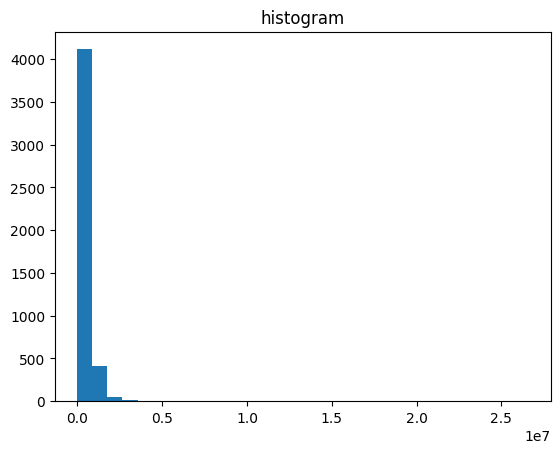

In [ ]:
plt.hist(df1["price"],bins=30)
plt.title("histogram")
plt.show()

In [ ]:
#8. Plot a countplot of Bedrooms. Which bedroom count is most common?

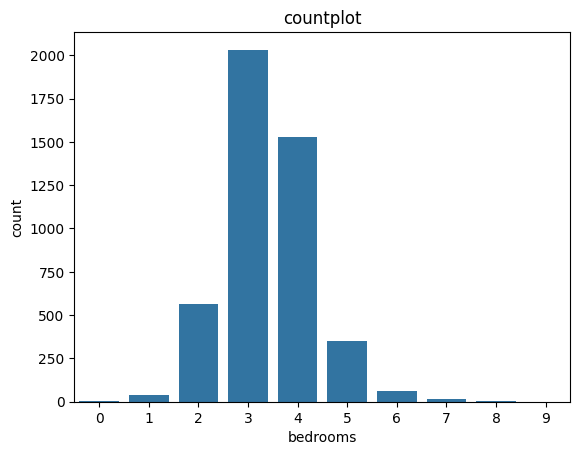

In [ ]:
sns.countplot(x = "bedrooms" , data=df1)
plt.title("countplot")
plt.show()

In [ ]:
#9. Plot a boxplot of Bathrooms. What insights do you get about bathroom distribution?


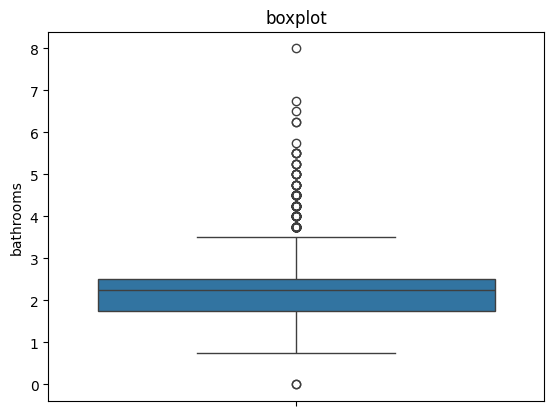

In [ ]:
sns.boxplot(df1["bathrooms"])
plt.title("boxplot")
plt.show()

8. BIVARIATE ANALYSIS

In [ ]:
#10. Create a scatter plot of Sqft_living vs Price. Do larger houses cost more?

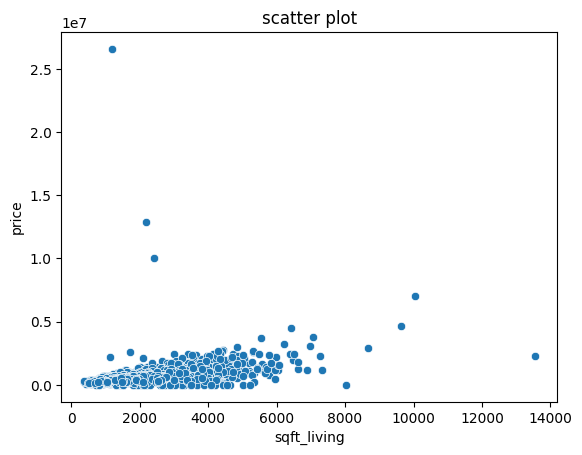

In [ ]:
sns.scatterplot(x="sqft_living",y="price",data = df1)
plt.title("scatter plot")
plt.show()

In [ ]:
#11. Create a boxplot of Waterfront vs Price. What is the effect of a waterfront view on house prices?

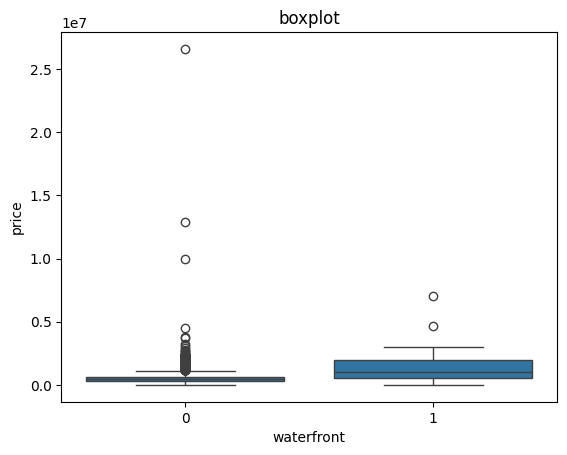

In [ ]:
sns.boxplot(x="waterfront",y="price",data=df1)
plt.title("boxplot")
plt.show()

In [ ]:
#12. Plot a correlation heatmap of numerical variables (Bedrooms, Bathrooms, Sqft_living, Floors, Price). Which variable has the strongest positive correlation with Price?

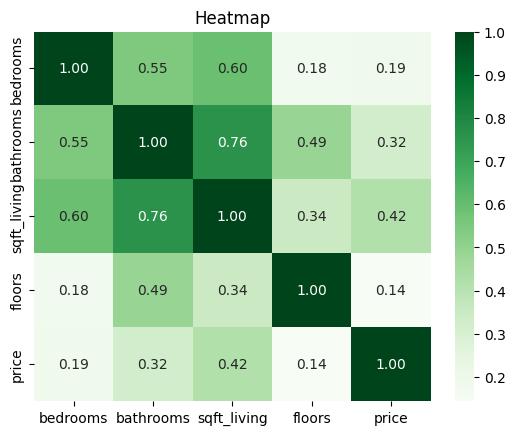

In [ ]:
w = ["bedrooms","bathrooms","sqft_living","floors","price"]
sns.heatmap(df1[w].corr(),annot=True,cmap="Greens",fmt = ".2f")
plt.title("Heatmap")
plt.show()

In [ ]:
b = df.groupby('city')['price'].mean().sort_values(ascending=False)
print(b)

city
Medina                 2.046559e+06
Clyde Hill             1.321945e+06
Yarrow Point           1.194838e+06
Mercer Island          1.123818e+06
Bellevue               8.516243e+05
Beaux Arts Village     7.450000e+05
Fall City              7.284500e+05
Sammamish              6.882779e+05
Redmond                6.669215e+05
Newcastle              6.660467e+05
Kirkland               6.527872e+05
Woodinville            6.131418e+05
North Bend             5.998082e+05
Issaquah               5.975969e+05
Seattle                5.793213e+05
Preston                5.624500e+05
Snoqualmie             5.324301e+05
Snoqualmie Pass        5.250000e+05
Carnation              5.194544e+05
Ravensdale             5.140714e+05
Normandy Park          5.128985e+05
Bothell                4.775833e+05
Vashon                 4.725569e+05
Lake Forest Park       4.480600e+05
Kenmore                4.474940e+05
Kent                   4.413312e+05
Inglewood-Finn Hill    4.250000e+05
Shoreline              

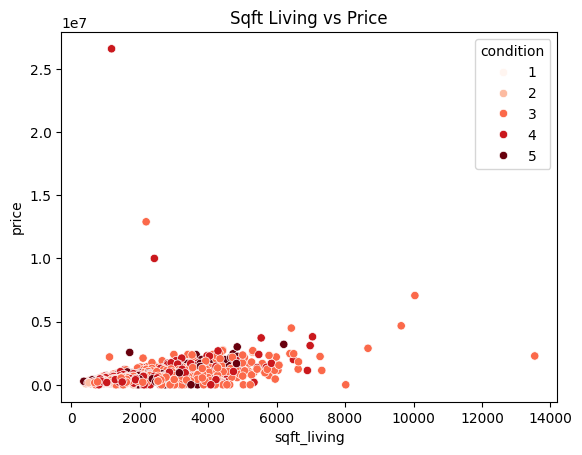

In [ ]:
sns.scatterplot(x='sqft_living', y='price', hue='condition', data=df1, palette ="Reds")
plt.title("Sqft Living vs Price")
plt.show()

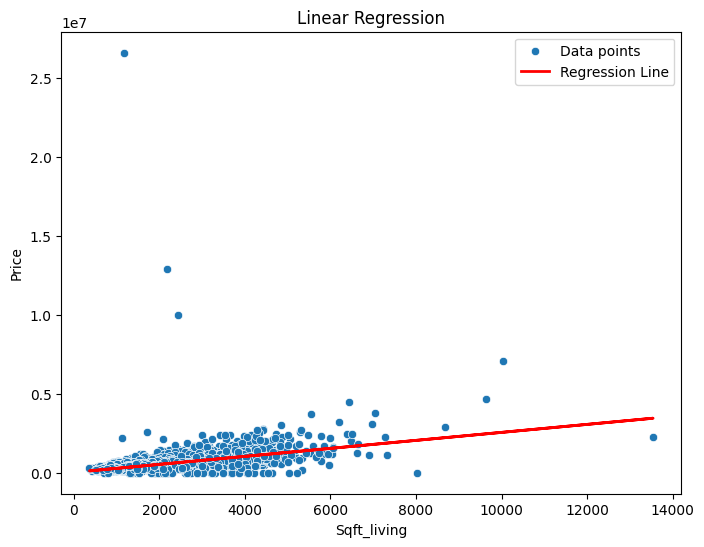

In [ ]:
df1 = df1.dropna(subset=['sqft_living', 'price'])

X = df1[['sqft_living']]
y = df1['price']

model = LinearRegression()
model.fit(X, y)

plt.figure(figsize=(8,6))
sns.scatterplot(x='sqft_living', y='price', data=df1, alpha=1, label="Data points")

plt.plot(X, model.predict(X), color='red', linewidth=2, label="Regression Line")

plt.title("Linear Regression")
plt.xlabel("Sqft_living")
plt.ylabel("Price")
plt.legend()
plt.show()


In [ ]:
X = df1[['sqft_living']]
y = df1['price']

q = sm.add_constant(X)

model = sm.OLS(y, q).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     971.0
Date:                Fri, 22 Aug 2025   Prob (F-statistic):          2.02e-193
Time:                        11:13:42   Log-Likelihood:                -66569.
No. Observations:                4560   AIC:                         1.331e+05
Df Residuals:                    4558   BIC:                         1.332e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.283e+04   1.91e+04      0.673      

1)House Size (Square Footage / Living Area): Larger houses with more living space tend to have significantly higher prices
2)Location (Neighborhood/Zip Code): Houses in premium or urban neighborhoods consistently show higher average prices compared to those in less developed areas.
3)Condition & Quality of Construction: Well-maintained houses or those with higher quality construction and modern renovations sell at a higher price.

1)Size: Medium-to-large houses (3–4 bedrooms) as they appeal to families and have strong resale value.
2)Condition: Recently renovated or well-maintained properties, since they require less repair cost and attract buyers willing to pay a premium.
3)Location: Properties in prime neighborhoods or areas with good connectivity, schools, and amenities, as location drives long-term appreciation and rental demand